# 基于深度学习的药物溶解度预测项目



## 1. 导入库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 化学信息学
from rdkit import Chem
from rdkit.Chem import Descriptors

# 深度学习
import torch
import torch.nn as nn
import torch.optim as optim

# 机器学习工具
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

print("库导入成功！")

库导入成功！


## 2. 加载ESOL溶解度数据集

ESOL数据集包含1128个化合物的实验溶解度数据

In [2]:
# 加载数据
data = pd.read_csv('delaney-processed.csv')

# 提取需要的列
data = data.rename(columns={
    'Compound ID': 'Name',
    'smiles': 'SMILES',
    'measured log solubility in mols per litre': 'LogS'
})
data = data[['Name', 'SMILES', 'LogS']]

print(f"数据集大小: {len(data)} 个分子")
print(f"\n溶解度范围: {data['LogS'].min():.2f} 到 {data['LogS'].max():.2f}")
print(f"溶解度均值: {data['LogS'].mean():.2f}")
print(f"\n前5个样本:")
print(data.head())

数据集大小: 1128 个分子

溶解度范围: -11.60 到 1.58
溶解度均值: -3.05

前5个样本:
        Name                                             SMILES  LogS
0  Amigdalin  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)... -0.77
1   Fenfuram                             Cc1occc1C(=O)Nc2ccccc2 -3.30
2     citral                               CC(C)=CCCC(C)=CC(=O) -2.06
3     Picene                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43 -7.87
4  Thiophene                                            c1ccsc1 -1.33


## 3. 计算分子描述符

使用RDKit从SMILES计算分子性质

In [3]:
def calculate_descriptors(smiles):
    """计算分子描述符"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    mol = Chem.AddHs(mol)  # 添加氢原子
    
    return {
        'MW': Descriptors.MolWt(mol),              # 分子量
        'LogP': Descriptors.MolLogP(mol),          # 脂水分配系数
        'NumHDonors': Descriptors.NumHDonors(mol), # 氢键供体
        'NumHAcceptors': Descriptors.NumHAcceptors(mol), # 氢键受体
        'TPSA': Descriptors.TPSA(mol),             # 极性表面积
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol), # 可旋转键
        'NumAromaticRings': Descriptors.NumAromaticRings(mol)    # 芳香环
    }

# 批量计算
print("计算分子描述符...")
descriptor_list = []
valid_indices = []

for idx, smiles in enumerate(data['SMILES']):
    desc = calculate_descriptors(smiles)
    if desc is not None:
        descriptor_list.append(desc)
        valid_indices.append(idx)

# 创建描述符DataFrame
descriptors_df = pd.DataFrame(descriptor_list)

print(f"成功计算: {len(descriptor_list)} 个分子")
print(f"\n描述符统计:")
print(descriptors_df.describe())

计算分子描述符...
成功计算: 1128 个分子

描述符统计:
                MW         LogP   NumHDonors  NumHAcceptors         TPSA  \
count  1128.000000  1128.000000  1128.000000    1128.000000  1128.000000   
mean    203.937074     2.447520     0.701241       2.111702    34.872881   
std     102.738077     1.852875     1.089727       2.153375    35.383593   
min      16.043000    -7.571400     0.000000       0.000000     0.000000   
25%     121.183000     1.414900     0.000000       0.000000     0.000000   
50%     182.179000     2.339000     0.000000       2.000000    26.300000   
75%     270.372000     3.402200     1.000000       3.000000    55.440000   
max     780.949000    10.388600    11.000000      16.000000   268.680000   

       NumRotatableBonds  NumAromaticRings  
count        1128.000000       1128.000000  
mean            3.892730          0.930851  
std             3.544622          1.005136  
min             0.000000          0.000000  
25%             1.000000          0.000000  
50%        

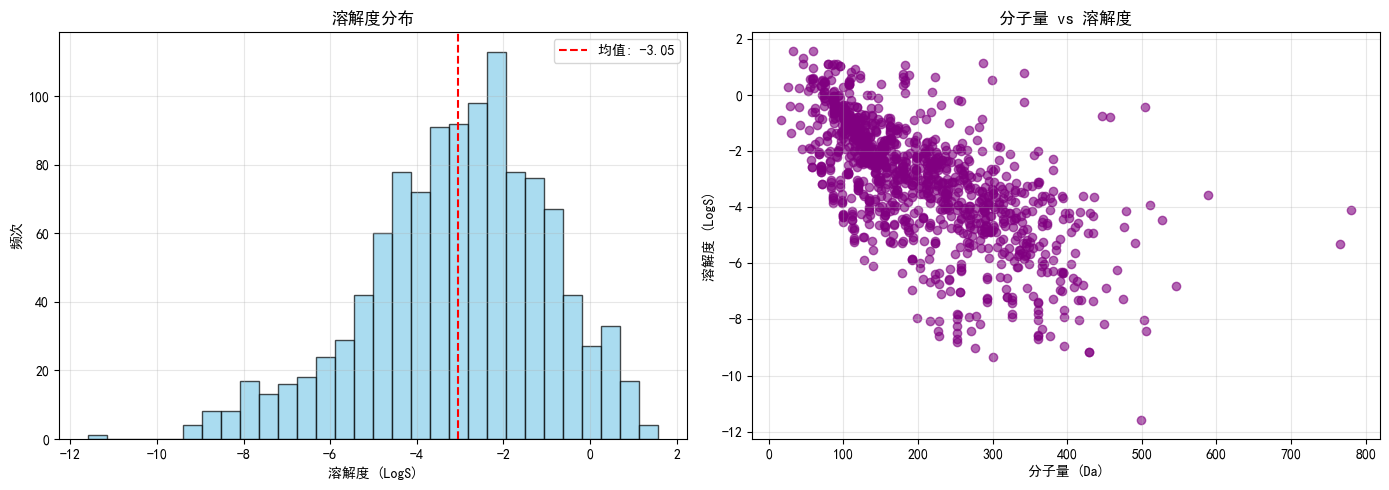

In [4]:
# 可视化溶解度分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 溶解度分布
axes[0].hist(data['LogS'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(data['LogS'].mean(), color='red', linestyle='--', 
                label=f'均值: {data["LogS"].mean():.2f}')
axes[0].set_xlabel('溶解度 (LogS)')
axes[0].set_ylabel('频次')
axes[0].set_title('溶解度分布')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 分子量 vs 溶解度
axes[1].scatter(descriptors_df['MW'], data.loc[valid_indices, 'LogS'], 
                alpha=0.6, color='purple')
axes[1].set_xlabel('分子量 (Da)')
axes[1].set_ylabel('溶解度 (LogS)')
axes[1].set_title('分子量 vs 溶解度')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 数据预处理

In [5]:
# 准备特征和目标
X = descriptors_df.values
y = data.loc[valid_indices, 'LogS'].values

print(f"特征矩阵: {X.shape}")
print(f"目标向量: {y.shape}")

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n标准化后特征范围: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"标准化后特征均值: {X_scaled.mean():.3f}")

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\n训练集: {len(X_train)} 样本")
print(f"测试集: {len(X_test)} 样本")

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

print(f"\nPyTorch张量准备完成")

特征矩阵: (1128, 7)
目标向量: (1128,)

标准化后特征范围: [-5.41, 9.45]
标准化后特征均值: 0.000

训练集: 902 样本
测试集: 226 样本

PyTorch张量准备完成


In [6]:
X_train_tensor

tensor([[-0.7963, -0.2368,  0.2743,  ..., -0.4140, -0.2520,  0.0688],
        [-1.2641, -0.7585, -0.6438,  ..., -0.7250,  0.0303, -0.9265],
        [ 0.0305,  0.6235, -0.6438,  ..., -0.9860, -1.0987,  1.0642],
        ...,
        [ 0.8211, -0.1253,  3.0285,  ...,  2.0456,  0.3125,  1.0642],
        [-0.6505, -0.8527, -0.6438,  ...,  0.1221, -0.5342,  0.0688],
        [-1.2833, -0.2133, -0.6438,  ..., -0.9860,  0.0303, -0.9265]])

## 5. 构建神经网络模型

In [7]:
class SolubilityNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(SolubilityNet, self).__init__()
        
        # 构建网络层
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        # 输出层（回归任务，不用激活函数）
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# 创建模型
input_size = X_train.shape[1]  # 7个特征
hidden_sizes = [64, 32, 16]     # 三层隐藏层
output_size = 1                 # 预测溶解度

model = SolubilityNet(input_size, hidden_sizes, output_size)

print("模型结构:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n总参数数: {total_params:,}")

模型结构:
SolubilityNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

总参数数: 3,137


## 6. 训练模型

### 四步训练循环
1. 前向传播
2. 损失计算
3. 反向传播
4. 参数更新

In [8]:
# 训练设置
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 500

# 记录训练历史
train_losses = []
test_losses = []
train_r2_scores = []
test_r2_scores = []

print("开始训练...")
print("=" * 60)

for epoch in range(epochs):
    # 训练模式
    model.train()
    
    # 1. 前向传播
    y_pred_train = model(X_train_tensor)
    
    # 2. 损失计算
    train_loss = criterion(y_pred_train, y_train_tensor)
    
    # 3. 反向传播
    optimizer.zero_grad()
    train_loss.backward()
    
    # 4. 参数更新
    optimizer.step()
    
    # 评估模式
    model.eval()
    with torch.no_grad():
        # 训练集评估
        y_pred_train_eval = model(X_train_tensor)
        train_r2 = r2_score(y_train_tensor.numpy(), y_pred_train_eval.numpy())
        
        # 测试集评估
        y_pred_test = model(X_test_tensor)
        test_loss = criterion(y_pred_test, y_test_tensor)
        test_r2 = r2_score(y_test_tensor.numpy(), y_pred_test.numpy())
    
    # 记录历史
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)
    
    # 打印进度
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] "
              f"Train Loss: {train_loss.item():.4f} "
              f"Test Loss: {test_loss.item():.4f} "
              f"Train R²: {train_r2:.4f} "
              f"Test R²: {test_r2:.4f}")

print("=" * 60)
print("训练完成！")

开始训练...
Epoch [ 50/500] Train Loss: 5.6290 Test Loss: 5.3146 Train R²: -0.2237 Test R²: -0.1244
Epoch [100/500] Train Loss: 1.2593 Test Loss: 1.4135 Train R²: 0.7094 Test R²: 0.7010
Epoch [150/500] Train Loss: 0.8805 Test Loss: 1.1041 Train R²: 0.7971 Test R²: 0.7664
Epoch [200/500] Train Loss: 0.6197 Test Loss: 0.8980 Train R²: 0.8570 Test R²: 0.8100
Epoch [250/500] Train Loss: 0.4825 Test Loss: 0.8139 Train R²: 0.8884 Test R²: 0.8278
Epoch [300/500] Train Loss: 0.4190 Test Loss: 0.7683 Train R²: 0.9029 Test R²: 0.8375
Epoch [350/500] Train Loss: 0.3827 Test Loss: 0.7405 Train R²: 0.9113 Test R²: 0.8433
Epoch [400/500] Train Loss: 0.3534 Test Loss: 0.7060 Train R²: 0.9181 Test R²: 0.8506
Epoch [450/500] Train Loss: 0.3294 Test Loss: 0.6830 Train R²: 0.9236 Test R²: 0.8555
Epoch [500/500] Train Loss: 0.3075 Test Loss: 0.6597 Train R²: 0.9287 Test R²: 0.8604
训练完成！


## 7. 训练过程可视化

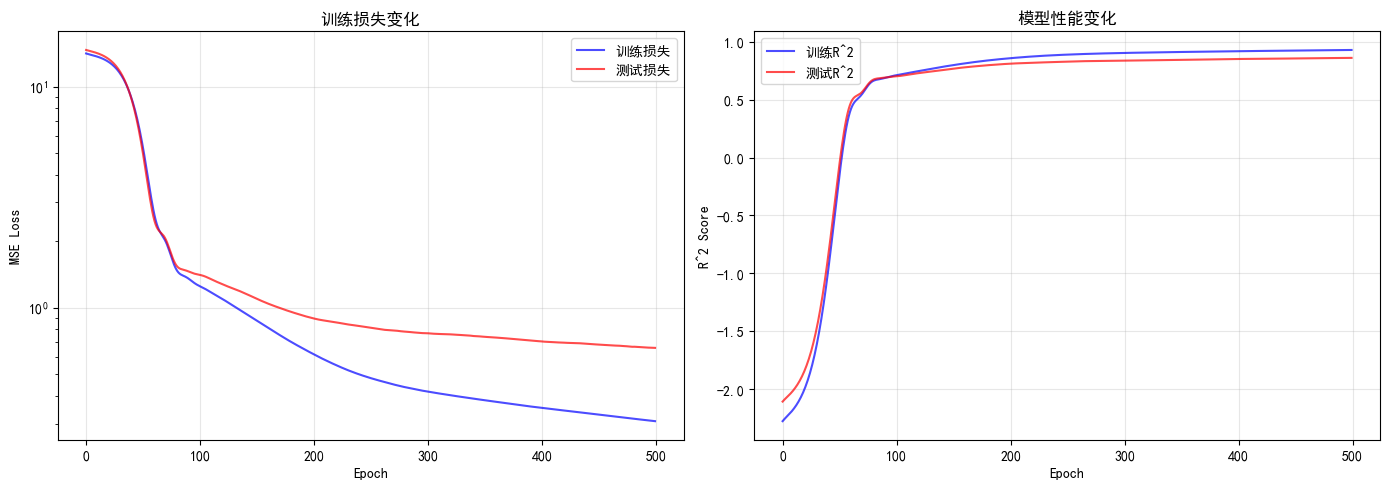


最终训练R^2: 0.9287
最终测试R^2: 0.8604


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(train_losses, label='训练损失', color='blue', alpha=0.7)
axes[0].plot(test_losses, label='测试损失', color='red', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('训练损失变化')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# R²分数
axes[1].plot(train_r2_scores, label='训练R^2', color='blue', alpha=0.7)
axes[1].plot(test_r2_scores, label='测试R^2', color='red', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R^2 Score')
axes[1].set_title('模型性能变化')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n最终训练R^2: {train_r2_scores[-1]:.4f}")
print(f"最终测试R^2: {test_r2_scores[-1]:.4f}")

## 8. 模型评估

In [10]:
# 获取最终预测
model.eval()
with torch.no_grad():
    y_pred_train_final = model(X_train_tensor).numpy().flatten()
    y_pred_test_final = model(X_test_tensor).numpy().flatten()

# 计算评价指标
def evaluate_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{name}性能:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MSE:      {mse:.4f}")
    print(f"  RMSE:     {rmse:.4f}")
    print(f"  MAE:      {mae:.4f}")
    
    return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}

train_metrics = evaluate_model(y_train, y_pred_train_final, "训练集")
test_metrics = evaluate_model(y_test, y_pred_test_final, "测试集")


训练集性能:
  R² Score: 0.9287
  MSE:      0.3071
  RMSE:     0.5541
  MAE:      0.4261

测试集性能:
  R² Score: 0.8604
  MSE:      0.6597
  RMSE:     0.8122
  MAE:      0.5637


## 9. 预测结果可视化

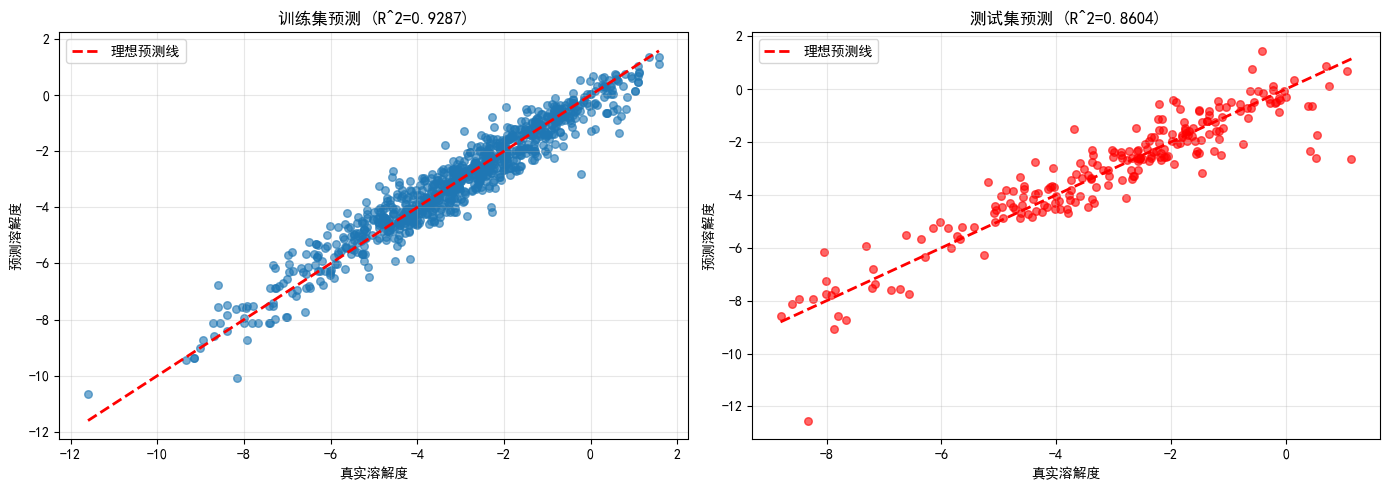


预测误差分析:
  误差均值: 0.0085
  误差标准差: 0.8122
  误差范围: [-4.20, 2.19]


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 训练集预测
axes[0].scatter(y_train, y_pred_train_final, alpha=0.6, s=30)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 
             'r--', lw=2, label='理想预测线')
axes[0].set_xlabel('真实溶解度')
axes[0].set_ylabel('预测溶解度')
axes[0].set_title(f'训练集预测 (R^2={train_metrics["r2"]:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 测试集预测
axes[1].scatter(y_test, y_pred_test_final, alpha=0.6, color='red', s=30)
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='理想预测线')
axes[1].set_xlabel('真实溶解度')
axes[1].set_ylabel('预测溶解度')
axes[1].set_title(f'测试集预测 (R^2={test_metrics["r2"]:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 误差分析
test_errors = y_pred_test_final - y_test
print(f"\n预测误差分析:")
print(f"  误差均值: {np.mean(test_errors):.4f}")
print(f"  误差标准差: {np.std(test_errors):.4f}")
print(f"  误差范围: [{test_errors.min():.2f}, {test_errors.max():.2f}]")

## 10. 预测新分子

In [12]:
def predict_solubility(smiles, name=""):
    """预测新分子的溶解度"""
    # 计算描述符
    desc = calculate_descriptors(smiles)
    if desc is None:
        print(f"错误: 无法解析SMILES {smiles}")
        return None
    
    # 准备特征
    features = np.array(list(desc.values())).reshape(1, -1)
    features_scaled = scaler.transform(features)
    features_tensor = torch.FloatTensor(features_scaled)
    
    # 预测
    model.eval()
    with torch.no_grad():
        pred = model(features_tensor).item()
    
    return pred

# 测试常见药物
test_molecules = [
    ("阿司匹林", "CC(=O)OC1=CC=CC=C1C(=O)O"),
    ("咖啡因", "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"),
    ("对乙酰氨基酚", "CC(=O)Nc1ccc(O)cc1"),
    ("布洛芬", "CC(C)Cc1ccc(cc1)C(C)C(=O)O")
]

print("预测新分子溶解度:")
print("=" * 60)

for name, smiles in test_molecules:
    pred = predict_solubility(smiles, name)
    if pred is not None:
        print(f"{name:12s} | LogS = {pred:6.3f} | SMILES: {smiles}")

预测新分子溶解度:
阿司匹林         | LogS = -2.259 | SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
咖啡因          | LogS = -0.664 | SMILES: CN1C=NC2=C1C(=O)N(C(=O)N2C)C
对乙酰氨基酚       | LogS = -1.440 | SMILES: CC(=O)Nc1ccc(O)cc1
布洛芬          | LogS = -2.942 | SMILES: CC(C)Cc1ccc(cc1)C(C)C(=O)O


## 11. 保存和加载模型

In [13]:
# 保存模型
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'feature_names': list(descriptors_df.columns),
    'test_r2': test_metrics['r2']
}, 'solubility_model_simple.pth')

print("模型已保存为 solubility_model_simple.pth")
print(f"测试集R²: {test_metrics['r2']:.4f}")

模型已保存为 solubility_model_simple.pth
测试集R²: 0.8604


In [14]:
# 加载模型
checkpoint = torch.load('solubility_model_simple.pth', weights_only=False)

# 重建模型
loaded_model = SolubilityNet(input_size, hidden_sizes, output_size)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print("✓ 模型加载成功")
print(f"模型测试R²: {checkpoint['test_r2']:.4f}")

# 验证加载的模型
test_smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"  # 阿司匹林
desc = calculate_descriptors(test_smiles)
features = np.array(list(desc.values())).reshape(1, -1)
features_scaled = checkpoint['scaler'].transform(features)
features_tensor = torch.FloatTensor(features_scaled)

with torch.no_grad():
    pred = loaded_model(features_tensor).item()

print(f"\n测试预测 (阿司匹林): LogS = {pred:.3f}")

✓ 模型加载成功
模型测试R²: 0.8604

测试预测 (阿司匹林): LogS = -2.259


## 13. 课后练习

1. 尝试添加更多分子描述符，看看能否提升性能
2. 调整网络结构（层数、神经元数）
3. 预测自己感兴趣的药物分子
4. 尝试预测其他分子性质（如毒性、活性）